# Kernel Density Estimator

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import pandas as pd

colors = ['#41AFAA', '#466EB4', '#00A0E1', '#E6A532', '#D7642C', '#AF4B91']

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
})

### Exercise 1 - fixed length hyper-cube KDE in 1D

In [4]:
# Fixed lenth hyper-cube KDE in 1D
data = [1, 2, 5, 6, 12, 15, 16, 16, 22, 22, 22, 23]

# Height fof the KDE
h = 1.5

def P_KDE_1D(x, N, h):
    """
    P_KDE = 1/N * sum(K(x-x_i/h)) where K(u) is a boxcar kernel: K(u) = 1/(2h) if |u| ≤ h, else 0.

    """
    K_values = np.where(np.abs((x - data) / h) <= 1, 1 / (2 * h), 0)            # Boxcar kernel values for each data point

    return 1/N * np.sum(K_values)

In [5]:
# Testing different specific x values
x_values = np.array([6, 10.1, 20.499, 20.501])

for x in x_values:
    print(f"P_KDE({x}) = {P_KDE_1D(x, len(data), h)}")

P_KDE(6.0) = 0.05555555555555555
P_KDE(10.1) = 0.0
P_KDE(20.499) = 0.0
P_KDE(20.501) = 0.08333333333333333


Result of normalization check: 0.9867506395284174


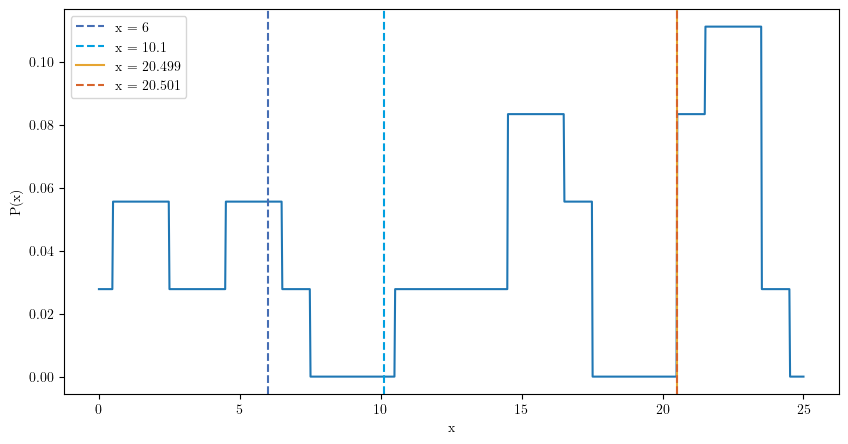

In [6]:
# Plotting the KDE
x_values = np.linspace(0, 25, 1000)
P_KDE_values = [P_KDE_1D(x, len(data), h) for x in x_values]

plt.figure(figsize = (10, 5))
plt.plot(x_values, P_KDE_values)
plt.axvline(x = 6, color = colors[1], linestyle = '--', label = 'x = 6')
plt.axvline(x = 10.1, color = colors[2], linestyle = '--', label = 'x = 10.1')
plt.axvline(x = 20.499, color = colors[3], linestyle = '-', label = 'x = 20.499')
plt.axvline(x = 20.501, color = colors[4], linestyle = '--', label = 'x = 20.501')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.legend()

# Checking if it is normalized
print('Result of normalization check:', np.trapz(P_KDE_values, x_values))

In [7]:
# Extending to 2D KDE
data_2D =  [(1,2), (2, 2.2), (5, 4.9), (6, 1.7), (12, 0.4), (15, 3.7), (16, 3.2), (16, 2.9), (22, 1.1), (22, 1.0), (22, 1.7), (23, 4.2)]
h_x, h_y = 1.5, 0.9

def P_KDE_2D(x, y, N, h_x, h_y):
    """
    P_KDE = 1/N * sum(K(x-x_i/h_x, y-y_i/h_y)) where K(u, v) is a boxcar kernel: K(u, v) = 1/(2h_x) * 1/(2h_y) if |u| ≤ h_x and |v| ≤ h_y, else 0.
    """

    K_values = np.where(np.abs((x - np.array(data_2D)[:,0]) / h_x) <= 1, 1 / (2 * h_x), 0) * np.where(np.abs((y - np.array(data_2D)[:,1]) / h_y) <= 1, 1 / (2 * h_y), 0)

    return 1/N * np.sum(K_values)

In [8]:
# Testing different specific x, y values
x_values = np.array([6, 10.2, 22.2])
y_values = np.array([1.7, 2.1, 2.1])

for x, y in zip(x_values, y_values):
    print(f"P_KDE({x}, {y}) = {P_KDE_2D(x, y, len(data_2D), h_x, h_y)}")

P_KDE(6.0, 1.7) = 0.015432098765432098
P_KDE(10.2, 2.1) = 0.0
P_KDE(22.2, 2.1) = 0.015432098765432098


Result of normalization check: 0.9329168981245299


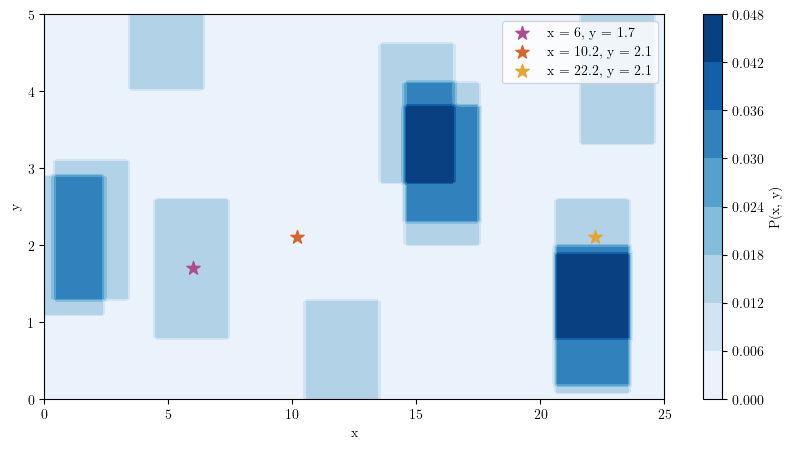

In [9]:
# Plotting the KDE
x_values = np.linspace(0, 25, 100)
y_values = np.linspace(0, 5, 100)
X, Y = np.meshgrid(x_values, y_values)

P_KDE_values = np.array([[P_KDE_2D(x, y, len(data_2D), h_x, h_y) for x in x_values] for y in y_values])

plt.figure(figsize = (10, 5))
plt.contourf(X, Y, P_KDE_values, cmap = 'Blues')
plt.colorbar(label = 'P(x, y)')
plt.scatter(6, 1.7, color = colors[5], marker = '*', s = 100, label = 'x = 6, y = 1.7')
plt.scatter(10.2, 2.1, color = colors[4], marker = '*', s = 100, label = 'x = 10.2, y = 2.1')
plt.scatter(22.2, 2.1, color = colors[3], marker = '*', s = 100, label = 'x = 22.2, y = 2.1')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# Checking if it is normalized
print('Result of normalization check:', np.trapz(np.trapz(P_KDE_values, x_values), y_values))

### Exercise 2 - Gaussian kernel

In [10]:
width = 3
data = [1, 2, 5, 6, 12, 15, 16, 16, 22, 22, 22, 23]

def P_KDE_gaussian_1D(width, x, N):
    """
    P_KDE = 1/N * sum(K(x-x_i, width)) where K(u) is a Gaussian kernel: K(u) = 1/(sqrt(2*pi)*width) * exp(-u^2/(2*width^2)).

    This function returns both the KDE value and the kernel values for each data point.
    """

    K_values = 1/(np.sqrt(2*np.pi)*width) * np.exp(-((x - np.array(data))**2)/(2*width**2))

    return 1/N * np.sum(K_values), K_values

# KDE from scipy
KDE = stats.gaussian_kde(data, bw_method = 0.35)

In [11]:
# Testing different specific x values
x_values_test = np.array([6, 10.1, 20.499, 20.501])

for x in x_values_test:
    print(f"P_KDE({x}) = {P_KDE_gaussian_1D(width, x, len(data))[0]}")

P_KDE(6.0) = 0.030592248162231567
P_KDE(10.1) = 0.022574352420610948
P_KDE(20.499) = 0.04662754739700865
P_KDE(20.501) = 0.046631580687783926


Result of normalization check: 0.9999826136852923


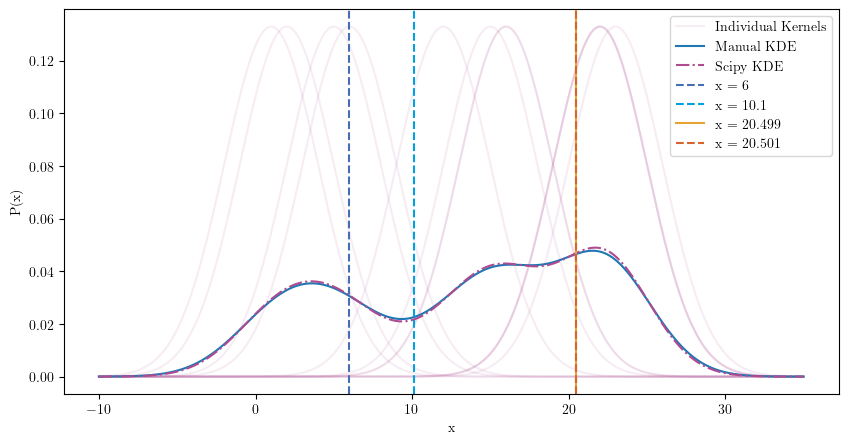

In [12]:
# Plotting the KDE
x_values = np.linspace(-10, 35, 1000)
P_KDE_values = [P_KDE_gaussian_1D(width, x, len(data))[0] for x in x_values]
P_KDE_individual_values = [P_KDE_gaussian_1D(width, x, len(data))[1] for x in x_values]

plt.figure(figsize = (10, 5))

# Plotting each individual kernel value
plt.plot(x_values, P_KDE_individual_values, color = colors[5], alpha = 0.1, label = 'Individual Kernels')

plt.plot(x_values, P_KDE_values, label = 'Manual KDE')
plt.plot(x_values, KDE(x_values), color = colors[5], label = 'Scipy KDE', linestyle = '-.')

plt.axvline(x = 6, color = colors[1], linestyle = '--', label = 'x = 6')
plt.axvline(x = 10.1, color = colors[2], linestyle = '--', label = 'x = 10.1')
plt.axvline(x = 20.499, color = colors[3], linestyle = '-', label = 'x = 20.499')
plt.axvline(x = 20.501, color = colors[4], linestyle = '--', label = 'x = 20.501')

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  

plt.legend(unique_labels.values(), unique_labels.keys())
plt.xlabel('x')
plt.ylabel('P(x)')

# Checking if it is normalized
print('Result of normalization check:', np.trapz(P_KDE_values, x_values))

### Exercise 3 - Epanechnikov kernel

In [43]:
def P_KDE_epanechinikov(bandwidth, x, N):
    """
    K(u) = (3/4)(1-u**2) for abs(u) ≤ 1, else 0
    """ 

    u = (x - np.array(data)) / bandwidth
    K_values = np.where(np.abs(u) <= 1, (3/4) * (1 - u**2), 0)

    return 1/N * np.sum(K_values), K_values

In [64]:
# Testing different specific x values - both the box, gaussian and Epanechnikov kernels to compare
x_values_test = np.array([6, 10.1, 20.499, 20.501])
data = [1, 2, 5, 6, 12, 15, 16, 16, 22, 22, 22, 23]
width = 1.5

print('Epanechnikov Kernel')
for x in x_values_test:
    print(f"P_KDE({x}) = {P_KDE_epanechinikov(width, x, len(data))[0]}")
    # Saving the values in an array
    P_KDE_epanechinikov_values = [P_KDE_epanechinikov(width, x, len(data))[0] for x in x_values_test]

print('')
print('Gaussian Kernel')
for x in x_values_test:
    print(f"P_KDE({x}) = {P_KDE_gaussian_1D(width, x, len(data))[0]}")
    # Saving the values in an array
    P_KDE_gaussian_values = [P_KDE_gaussian_1D(width, x, len(data))[0] for x in x_values_test]

print('')
print('Boxcar Kernel')
for x in x_values_test:
    print(f"P_KDE({x}) = {P_KDE_1D(x, len(data), width)}")
    # Saving the values in an array
    P_KDE_boxcar_values = [P_KDE_1D(x, len(data), width) for x in x_values_test]

Epanechnikov Kernel
P_KDE(6.0) = 0.09722222222222222
P_KDE(10.1) = 0.0
P_KDE(20.499) = 0.0
P_KDE(20.501) = 0.0002499166666669675

Gaussian Kernel
P_KDE(6.0) = 0.040636799301318846
P_KDE(10.1) = 0.01066000190247162
P_KDE(20.499) = 0.04634210048379737
P_KDE(20.501) = 0.04640605270290174

Boxcar Kernel
P_KDE(6.0) = 0.05555555555555555
P_KDE(10.1) = 0.0
P_KDE(20.499) = 0.0
P_KDE(20.501) = 0.08333333333333333


Result of normalization check (Epanechinikov): 1.499999867979334
Result of normalization check (Gaussian): 0.9999999999999905
Result of normalization check (Boxcar): 0.9984984984984981


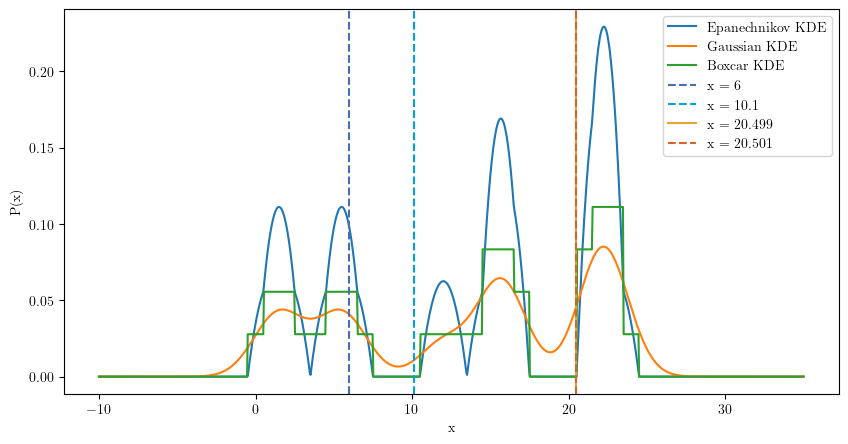

In [65]:
# Plotting the KDEs
x_values = np.linspace(-10, 35, 1000)
P_KDE_values_epanechinikov = [P_KDE_epanechinikov(width, x, len(data))[0] for x in x_values]
P_KDE_values_gaussian = [P_KDE_gaussian_1D(width, x, len(data))[0] for x in x_values]
P_KDE_values_boxcar = [P_KDE_1D(x, len(data), h) for x in x_values]

plt.figure(figsize = (10, 5))

plt.plot(x_values, P_KDE_values_epanechinikov, label = 'Epanechnikov KDE')
plt.plot(x_values, P_KDE_values_gaussian, label = 'Gaussian KDE')
plt.plot(x_values, P_KDE_values_boxcar, label = 'Boxcar KDE')

plt.axvline(x = 6, color = colors[1], linestyle = '--', label = 'x = 6')
plt.axvline(x = 10.1, color = colors[2], linestyle = '--', label = 'x = 10.1')
plt.axvline(x = 20.499, color = colors[3], linestyle = '-', label = 'x = 20.499')
plt.axvline(x = 20.501, color = colors[4], linestyle = '--', label = 'x = 20.501')

plt.legend()

plt.xlabel('x')
plt.ylabel('P(x)')

# Checking if it is normalized
print('Result of normalization check (Epanechinikov):', np.trapz(P_KDE_values_epanechinikov, x_values))
print('Result of normalization check (Gaussian):', np.trapz(P_KDE_values_gaussian, x_values))
print('Result of normalization check (Boxcar):', np.trapz(P_KDE_values_boxcar, x_values))

In [66]:
# Making a dataframe 
df = pd.DataFrame({'x': x_values_test, 'Epanechnikov': P_KDE_epanechinikov_values, 'Gaussian': P_KDE_gaussian_values, 'Boxcar': P_KDE_boxcar_values})
print(df)

        x  Epanechnikov  Gaussian    Boxcar
0   6.000      0.097222  0.040637  0.055556
1  10.100      0.000000  0.010660  0.000000
2  20.499      0.000000  0.046342  0.000000
3  20.501      0.000250  0.046406  0.083333


### Exercise 5 - 2D KDE 
Using the 500 pseudo-experiment bootstrap from Lecture “Parameter Estimation and Confidence Intervals” exercise 2b